In [1]:
# ============================================
# Cell 1: Imports, warnings, plotting setup, and project paths
# Purpose:
# - Load all dependencies required for the optimized quantitative model layer
# - Keep project paths consistent with the corrected folder structure
# - Prepare plotting for diagnostics and reporting
# ============================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
META_DIR = REPORT_DIR / "metadata"

for folder in [DATA_DIR, PROCESSED_DIR, REPORT_DIR, FIG_DIR, META_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_START = "2015-01-01"
TRAIN_END = "2024-12-31"
LIVE_START = "2025-01-01"
LIVE_END = "2026-03-01"

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)

Project root: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha
Processed directory: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed


In [2]:
# ============================================
# Cell 2: Load Phase 3.1 optimized target dataset
# Purpose:
# - Load the optimized feature + target dataset from Phase 3.1
# - Preserve strict time ordering
# - Confirm the optimized handoff contract before building quant logic
# ============================================

phase_3_1_parquet = PROCESSED_DIR / "phase_3_1_target_data.parquet"
phase_3_1_csv = PROCESSED_DIR / "phase_3_1_target_data.csv"

print("Looking for Phase 3.1 files:")
print("Parquet:", phase_3_1_parquet)
print("CSV:", phase_3_1_csv)

if phase_3_1_parquet.exists():
    df = pd.read_parquet(phase_3_1_parquet)
    print("Loaded Parquet file")
elif phase_3_1_csv.exists():
    df = pd.read_csv(phase_3_1_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 3.1 data file was not found. "
        f"Expected one of:\n{phase_3_1_parquet}\n{phase_3_1_csv}"
    )

df.index = pd.to_datetime(df.index)
df = df.sort_index()

print("\nDataset shape:", df.shape)
print("\nDataset preview:")
print(df.head())

Looking for Phase 3.1 files:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_3_1_target_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_3_1_target_data.csv
Loaded Parquet file

Dataset shape: (2770, 73)

Dataset preview:
              spy_open    spy_high     spy_low   spy_close  spy_adj_close  \
Date                                                                        
2015-02-02  200.050003  202.029999  197.860001  201.919998     167.218262   
2015-02-03  203.000000  204.850006  202.550003  204.839996     169.636398   
2015-02-04  203.919998  205.380005  203.509995  204.059998     168.990479   
2015-02-05  204.860001  206.300003  204.770004  206.119995     170.696411   
2015-02-06  206.559998  207.240005  204.919998  205.550003     170.224442   

            spy_volume  vix_close  tnx_close  is_train_period  is_live_period  \
Date                                                                            
2015

In [3]:
# ============================================
# Cell 3: Validation before optimized quant modeling
# Purpose:
# - Confirm the optimized dataset contains the required structural inputs
# - Fail early if any critical optimized features or targets are missing
# - Prevent silent downstream errors in regime and signal logic
# ============================================

required_cols = [
    "spy_close",
    "spy_open",
    "spy_high",
    "spy_low",
    "spy_volume",
    "vix_close",
    "tnx_close",
    "phase_2_5_regime_proxy",
    "target_return_5d",
    "target_return_10d",
    "target_signal_5d",
    "target_signal_10d",
    "target_score_5d",
    "target_score_10d",
    "realized_vol_20",
    "realized_vol_60",
    "realized_vol_120",
    "price_to_sma_100",
    "price_to_sma_200",
    "atr_pct_14",
    "drawdown_252",
    "sma_20_50_spread",
    "vix_level",
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for Phase 4.1: {missing_cols}")

assert df.index.is_monotonic_increasing, "Index must be sorted ascending."
assert df.index.duplicated().sum() == 0, "Duplicate timestamps are not allowed."

print("Phase 4.1 validation passed successfully.")

Phase 4.1 validation passed successfully.


In [4]:
# ============================================
# Cell 4: Helper functions for optimized quantitative models
# Purpose:
# - Centralize regime, signal, and scoring logic
# - Keep all quant rules interpretable and explicit
# - Make the optimized quant layer easier to debug and tune
# ============================================

def safe_rank_pct(series: pd.Series) -> pd.Series:
    return series.rank(pct=True)


def expanding_zscore(series: pd.Series, min_periods: int = 60) -> pd.Series:
    """
    Expanding z-score using only past data up to time t.
    """
    exp_mean = series.expanding(min_periods=min_periods).mean()
    exp_std = series.expanding(min_periods=min_periods).std()
    return (series - exp_mean) / exp_std.replace(0, np.nan)


def map_regime_names_from_gmm(raw_labels: pd.Series, vol_series: pd.Series, trend_series: pd.Series, risk_series: pd.Series) -> pd.Series:
    """
    Convert numeric GMM labels into interpretable regime names using cluster statistics.
    Heuristic mapping:
    - highest volatility cluster -> high_volatility
    - strongest positive trend among remaining -> trending
    - most negative trend among remaining -> mean_reverting
    - leftover cluster -> transition
    """
    stats = (
        pd.DataFrame({
            "label": raw_labels,
            "vol": vol_series,
            "trend": trend_series,
            "risk": risk_series,
        })
        .dropna()
        .groupby("label")
        .agg(
            avg_vol=("vol", "mean"),
            avg_trend=("trend", "mean"),
            avg_risk=("risk", "mean"),
        )
        .sort_index()
    )

    if stats.empty:
        return pd.Series(index=raw_labels.index, dtype="object")

    regime_map = {}

    high_vol_label = stats["avg_vol"].idxmax()
    regime_map[high_vol_label] = "high_volatility"

    remaining = stats.index.difference([high_vol_label])

    if len(remaining) >= 1:
        trending_label = stats.loc[remaining, "avg_trend"].idxmax()
        regime_map[trending_label] = "trending"
        remaining = remaining.difference([trending_label])

    if len(remaining) >= 1:
        mean_reverting_label = stats.loc[remaining, "avg_trend"].idxmin()
        regime_map[mean_reverting_label] = "mean_reverting"
        remaining = remaining.difference([mean_reverting_label])

    for label in remaining:
        regime_map[label] = "transition"

    return raw_labels.map(regime_map)


def build_trend_model_signal(price_to_sma_100: pd.Series, price_to_sma_200: pd.Series, sma_spread: pd.Series, slope_50: pd.Series, slope_100: pd.Series) -> pd.Series:
    """
    Trend model:
    1 when medium- and long-term structure is constructive, else 0.
    """
    signal = (
        (price_to_sma_100 > 0) &
        (price_to_sma_200 > 0) &
        (sma_spread > 0) &
        (slope_50 > 0) &
        (slope_100 > 0)
    ).astype(int)
    return signal


def build_mean_reversion_model_signal(zscore_proxy: pd.Series, drawdown: pd.Series, downside_tail: pd.Series) -> pd.Series:
    """
    Mean-reversion model:
    +1 when the market is stretched down but not structurally broken.
    -1 when overextended upward.
    0 otherwise.
    """
    signal = pd.Series(0, index=zscore_proxy.index, dtype=int)

    signal[(zscore_proxy < -1.0) & (drawdown < -0.03) & (downside_tail > downside_tail.rolling(252, min_periods=60).median())] = 1
    signal[(zscore_proxy > 1.0) & (drawdown > -0.01)] = -1

    return signal


def build_risk_filter(realized_vol_20: pd.Series, realized_vol_120: pd.Series, atr_pct_14: pd.Series, vix_level: pd.Series, drawdown_252: pd.Series) -> pd.Series:
    """
    Risk filter:
    1 when risk conditions are acceptable
    0 when conditions are hostile
    """
    filter_signal = (
        (realized_vol_20 < realized_vol_120 * 1.35) &
        (atr_pct_14 < atr_pct_14.rolling(252, min_periods=60).quantile(0.85)) &
        (vix_level < vix_level.rolling(252, min_periods=60).quantile(0.85)) &
        (drawdown_252 > -0.20)
    ).astype(int)

    return filter_signal


def compute_directional_hit_rate(signal: pd.Series, forward_return: pd.Series) -> float:
    active = signal != 0
    if active.sum() == 0:
        return np.nan

    correct = (
        ((signal[active] > 0) & (forward_return[active] > 0)) |
        ((signal[active] < 0) & (forward_return[active] < 0))
    )

    return float(correct.mean())

In [5]:
# ============================================
# Cell 5: Build optimized trend, mean-reversion, and risk components
# Purpose:
# - Use the new optimized feature stack to create cleaner structural quant signals
# - Focus on the features that Phase 2.5 identified as strongest
# - Keep the signals interpretable and economically sensible
# ============================================

quant_df = df.copy()

# If slope features are not in the selected optimized dataset, reconstruct a simple proxy.
if "sma_slope_50" not in quant_df.columns:
    quant_df["sma_slope_50"] = quant_df["spy_close"].rolling(50).mean().diff(5)
if "sma_slope_100" not in quant_df.columns:
    quant_df["sma_slope_100"] = quant_df["spy_close"].rolling(100).mean().diff(5)
if "zscore_20" not in quant_df.columns:
    rolling_mean_20 = quant_df["spy_close"].rolling(20).mean()
    rolling_std_20 = quant_df["spy_close"].rolling(20).std()
    quant_df["zscore_20"] = (quant_df["spy_close"] - rolling_mean_20) / rolling_std_20.replace(0, np.nan)
if "downside_tail_freq_60" not in quant_df.columns:
    ret_1d = quant_df["spy_close"].pct_change()
    quant_df["downside_tail_freq_60"] = (ret_1d < -0.01).rolling(60).mean()

quant_df["quant_trend_signal"] = build_trend_model_signal(
    price_to_sma_100=quant_df["price_to_sma_100"],
    price_to_sma_200=quant_df["price_to_sma_200"],
    sma_spread=quant_df["sma_20_50_spread"],
    slope_50=quant_df["sma_slope_50"],
    slope_100=quant_df["sma_slope_100"],
)

quant_df["quant_trend_strength"] = (
    quant_df["price_to_sma_100"].fillna(0.0) * 0.25 +
    quant_df["price_to_sma_200"].fillna(0.0) * 0.30 +
    quant_df["sma_20_50_spread"].fillna(0.0) * 0.20 +
    expanding_zscore(quant_df["sma_slope_50"], min_periods=60).fillna(0.0) * 0.15 +
    expanding_zscore(quant_df["sma_slope_100"], min_periods=60).fillna(0.0) * 0.10
)

quant_df["quant_mean_reversion_signal"] = build_mean_reversion_model_signal(
    zscore_proxy=quant_df["zscore_20"],
    drawdown=quant_df["drawdown_252"],
    downside_tail=quant_df["downside_tail_freq_60"],
)

quant_df["quant_mean_reversion_strength"] = (
    -quant_df["zscore_20"].fillna(0.0) * 0.50 +
    -expanding_zscore(quant_df["drawdown_252"], min_periods=60).fillna(0.0) * 0.30 +
    expanding_zscore(quant_df["downside_tail_freq_60"], min_periods=60).fillna(0.0) * 0.20
)

quant_df["quant_risk_filter"] = build_risk_filter(
    realized_vol_20=quant_df["realized_vol_20"],
    realized_vol_120=quant_df["realized_vol_120"],
    atr_pct_14=quant_df["atr_pct_14"],
    vix_level=quant_df["vix_level"],
    drawdown_252=quant_df["drawdown_252"],
)

quant_df["quant_risk_score"] = (
    safe_rank_pct(quant_df["realized_vol_20"]).fillna(0.5) * 0.25 +
    safe_rank_pct(quant_df["realized_vol_120"]).fillna(0.5) * 0.20 +
    safe_rank_pct(quant_df["atr_pct_14"]).fillna(0.5) * 0.20 +
    safe_rank_pct(quant_df["vix_level"]).fillna(0.5) * 0.20 +
    safe_rank_pct(-quant_df["drawdown_252"]).fillna(0.5) * 0.15
)

print("Optimized quant components created.")
print(
    quant_df[
        [
            "quant_trend_signal",
            "quant_trend_strength",
            "quant_mean_reversion_signal",
            "quant_mean_reversion_strength",
            "quant_risk_filter",
            "quant_risk_score",
        ]
    ].head()
)

Optimized quant components created.
            quant_trend_signal  quant_trend_strength  \
Date                                                   
2015-02-02                   0             -0.000990   
2015-02-03                   0              0.005577   
2015-02-04                   0              0.013595   
2015-02-05                   0              0.011498   
2015-02-06                   0              0.017147   

            quant_mean_reversion_signal  quant_mean_reversion_strength  \
Date                                                                     
2015-02-02                            0                            0.0   
2015-02-03                            0                            0.0   
2015-02-04                            0                            0.0   
2015-02-05                            0                            0.0   
2015-02-06                            0                            0.0   

            quant_risk_filter  quant_risk_score  
Da

In [6]:
# ============================================
# Cell 6: Build optimized regime model with Gaussian Mixture
# Purpose:
# - Use the optimized feature stack to create a more informative regime model
# - Fit only on the training period
# - Produce regime labels and probabilities for later ML and ensemble conditioning
# ============================================

regime_feature_cols = [
    "realized_vol_20",
    "realized_vol_60",
    "realized_vol_120",
    "price_to_sma_100",
    "price_to_sma_200",
    "drawdown_252",
    "atr_pct_14",
    "vix_level",
]

regime_features = quant_df[regime_feature_cols].copy()
regime_features = regime_features.replace([np.inf, -np.inf], np.nan).dropna().copy()

train_mask = (
    (regime_features.index >= pd.Timestamp(TRAIN_START)) &
    (regime_features.index <= pd.Timestamp(TRAIN_END))
)

regime_train = regime_features.loc[train_mask].copy()
if len(regime_train) == 0:
    raise ValueError("No regime training data found inside the training window.")

gmm = GaussianMixture(
    n_components=4,
    covariance_type="full",
    random_state=42,
    n_init=10,
)

gmm.fit(regime_train)

regime_labels_numeric = pd.Series(
    gmm.predict(regime_features),
    index=regime_features.index,
    name="quant_regime_label_numeric",
)

regime_names = map_regime_names_from_gmm(
    raw_labels=regime_labels_numeric,
    vol_series=regime_features["realized_vol_20"],
    trend_series=regime_features["price_to_sma_200"],
    risk_series=regime_features["drawdown_252"],
)

quant_df["quant_regime_label_numeric"] = regime_labels_numeric.reindex(quant_df.index)
quant_df["quant_regime_label"] = regime_names.reindex(quant_df.index)

regime_probability_array = gmm.predict_proba(regime_features)
for i in range(regime_probability_array.shape[1]):
    quant_df[f"quant_regime_prob_{i}"] = pd.Series(
        regime_probability_array[:, i],
        index=regime_features.index,
    ).reindex(quant_df.index)

print("Optimized regime model created.")
print(quant_df["quant_regime_label"].value_counts(dropna=False))

Optimized regime model created.
quant_regime_label
trending           1450
mean_reverting     1128
transition          120
high_volatility      72
Name: count, dtype: int64


In [7]:
# ============================================
# Cell 7: Build optimized composite quant signal
# Purpose:
# - Combine trend, mean-reversion, regime, and risk into one optimized quant layer
# - Bias toward participating in constructive trends while respecting hostile regimes
# - Produce a cleaner quant score for the optimized ensemble phase
# ============================================

quant_df["quant_signal_raw"] = 0

# Trending regime: participate with the trend model.
trend_regime_mask = quant_df["quant_regime_label"].eq("trending")
quant_df.loc[trend_regime_mask & (quant_df["quant_trend_signal"] == 1), "quant_signal_raw"] = 1

# Mean-reverting regime: allow oversold re-entry only.
mr_regime_mask = quant_df["quant_regime_label"].eq("mean_reverting")
quant_df.loc[mr_regime_mask & (quant_df["quant_mean_reversion_signal"] == 1), "quant_signal_raw"] = 1

# Transition regime: require both constructive trend and acceptable risk.
transition_mask = quant_df["quant_regime_label"].eq("transition")
quant_df.loc[
    transition_mask &
    (quant_df["quant_trend_signal"] == 1) &
    (quant_df["quant_risk_filter"] == 1),
    "quant_signal_raw"
] = 1

# High volatility regime: stand aside unless the drawdown has stabilized and trend is still positive.
high_vol_mask = quant_df["quant_regime_label"].eq("high_volatility")
quant_df.loc[
    high_vol_mask &
    (quant_df["quant_trend_signal"] == 1) &
    (quant_df["drawdown_252"] > -0.08) &
    (quant_df["quant_risk_filter"] == 1),
    "quant_signal_raw"
] = 1

# Final risk gate
quant_df["quant_signal"] = np.where(
    quant_df["quant_risk_filter"] == 1,
    quant_df["quant_signal_raw"],
    0
)

quant_df["quant_score"] = (
    quant_df["quant_trend_strength"].fillna(0.0) * 0.55 +
    quant_df["quant_mean_reversion_strength"].fillna(0.0) * 0.15 -
    quant_df["quant_risk_score"].fillna(0.0) * 0.30
)

print("Optimized composite quant signal created.")
print(
    quant_df[
        [
            "quant_signal_raw",
            "quant_signal",
            "quant_score",
        ]
    ].head()
)

Optimized composite quant signal created.
            quant_signal_raw  quant_signal  quant_score
Date                                                   
2015-02-02                 0             0    -0.202005
2015-02-03                 0             0    -0.194196
2015-02-04                 0             0    -0.175480
2015-02-05                 0             0    -0.179167
2015-02-06                 0             0    -0.164055


In [8]:
# ============================================
# Cell 7: Build optimized composite quant signal
# Purpose:
# - Combine trend, mean-reversion, regime, and risk into one optimized quant layer
# - Bias toward participating in constructive trends while respecting hostile regimes
# - Produce a cleaner quant score for the optimized ensemble phase
# ============================================

quant_df["quant_signal_raw"] = 0

# Trending regime: participate with the trend model.
trend_regime_mask = quant_df["quant_regime_label"].eq("trending")
quant_df.loc[trend_regime_mask & (quant_df["quant_trend_signal"] == 1), "quant_signal_raw"] = 1

# Mean-reverting regime: allow oversold re-entry only.
mr_regime_mask = quant_df["quant_regime_label"].eq("mean_reverting")
quant_df.loc[mr_regime_mask & (quant_df["quant_mean_reversion_signal"] == 1), "quant_signal_raw"] = 1

# Transition regime: require both constructive trend and acceptable risk.
transition_mask = quant_df["quant_regime_label"].eq("transition")
quant_df.loc[
    transition_mask &
    (quant_df["quant_trend_signal"] == 1) &
    (quant_df["quant_risk_filter"] == 1),
    "quant_signal_raw"
] = 1

# High volatility regime: stand aside unless the drawdown has stabilized and trend is still positive.
high_vol_mask = quant_df["quant_regime_label"].eq("high_volatility")
quant_df.loc[
    high_vol_mask &
    (quant_df["quant_trend_signal"] == 1) &
    (quant_df["drawdown_252"] > -0.08) &
    (quant_df["quant_risk_filter"] == 1),
    "quant_signal_raw"
] = 1

# Final risk gate
quant_df["quant_signal"] = np.where(
    quant_df["quant_risk_filter"] == 1,
    quant_df["quant_signal_raw"],
    0
)

quant_df["quant_score"] = (
    quant_df["quant_trend_strength"].fillna(0.0) * 0.55 +
    quant_df["quant_mean_reversion_strength"].fillna(0.0) * 0.15 -
    quant_df["quant_risk_score"].fillna(0.0) * 0.30
)

print("Optimized composite quant signal created.")
print(
    quant_df[
        [
            "quant_signal_raw",
            "quant_signal",
            "quant_score",
        ]
    ].head()
)

Optimized composite quant signal created.
            quant_signal_raw  quant_signal  quant_score
Date                                                   
2015-02-02                 0             0    -0.202005
2015-02-03                 0             0    -0.194196
2015-02-04                 0             0    -0.175480
2015-02-05                 0             0    -0.179167
2015-02-06                 0             0    -0.164055


In [9]:
# ============================================
# Cell 8: Quant baseline diagnostics using optimized targets
# Purpose:
# - Evaluate the optimized quant layer before ML is reintroduced
# - Compare directional usefulness against the prior simpler quant layer
# - Keep this as the clean structural baseline for the optimized pipeline
# ============================================

quant_eval = quant_df.copy()

# Use the 5-day optimized signal target as the directional performance reference.
quant_eval["quant_position_next_day"] = quant_eval["quant_signal"].shift(1).fillna(0)
quant_eval["quant_strategy_return_1d"] = quant_eval["quant_position_next_day"] * quant_eval["target_return_1d"]
quant_eval["buy_hold_return_1d"] = quant_eval["target_return_1d"]

quant_eval["quant_equity_curve"] = (1.0 + quant_eval["quant_strategy_return_1d"].fillna(0.0)).cumprod()
quant_eval["buy_hold_equity_curve"] = (1.0 + quant_eval["buy_hold_return_1d"].fillna(0.0)).cumprod()

quant_hit_rate = compute_directional_hit_rate(
    signal=quant_eval["quant_signal"],
    forward_return=quant_eval["target_return_5d"],
)

quant_active_days = int((quant_eval["quant_signal"] != 0).sum())
quant_exposure_rate = float((quant_eval["quant_position_next_day"] > 0).mean())

print("Optimized quant signal diagnostics")
print("---------------------------------")
print("Active signal days:", quant_active_days)
print("Exposure rate:", round(quant_exposure_rate, 4))
print("Directional 5-day hit rate:", round(quant_hit_rate, 4) if pd.notna(quant_hit_rate) else np.nan)

print("\nFinal equity values")
print("Optimized quant baseline:", round(float(quant_eval["quant_equity_curve"].iloc[-1]), 4))
print("Buy and hold:", round(float(quant_eval["buy_hold_equity_curve"].iloc[-1]), 4))

Optimized quant signal diagnostics
---------------------------------
Active signal days: 1196
Exposure rate: 0.4314
Directional 5-day hit rate: 0.6129

Final equity values
Optimized quant baseline: 1.5099
Buy and hold: 3.4203


In [10]:
# ============================================
# Cell 9: Regime-aware summary table
# Purpose:
# - Inspect whether the optimized quant logic behaves differently across regimes
# - Confirm that the regime-aware design is active and meaningful
# - Save an interpretable summary for downstream comparison
# ============================================

regime_summary = (
    quant_df.groupby("quant_regime_label")
    .agg(
        rows=("quant_signal", "size"),
        buy_signals=("quant_signal", "sum"),
        avg_quant_score=("quant_score", "mean"),
        avg_risk_score=("quant_risk_score", "mean"),
        avg_target_return_5d=("target_return_5d", "mean"),
    )
    .sort_values("rows", ascending=False)
)

print("Optimized regime summary:")
print(regime_summary)

Optimized regime summary:
                    rows  buy_signals  avg_quant_score  avg_risk_score  \
quant_regime_label                                                       
trending            1450         1085        -0.079510        0.321126   
mean_reverting      1128           29        -0.181778        0.673239   
transition           120           82        -0.027780        0.770726   
high_volatility       72            0        -0.439149        0.943986   

                    avg_target_return_5d  
quant_regime_label                        
trending                        0.001433  
mean_reverting                  0.003032  
transition                      0.009395  
high_volatility                 0.002766  


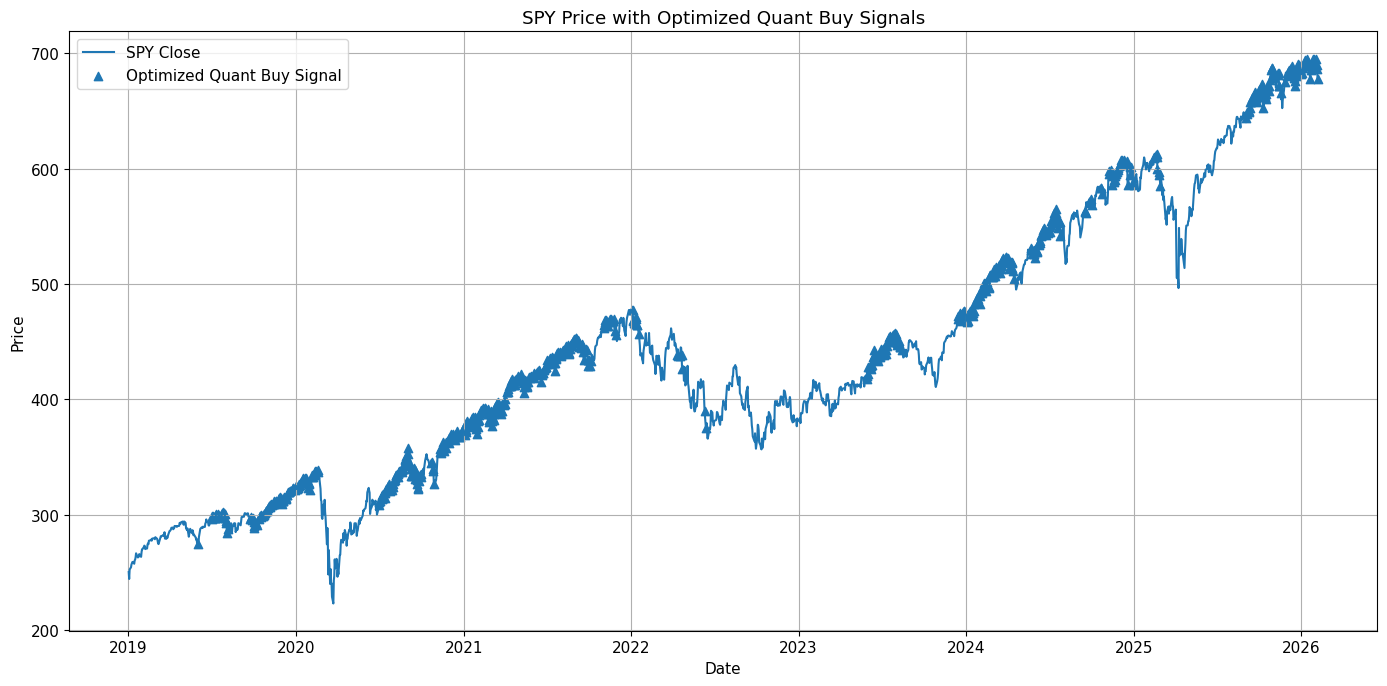

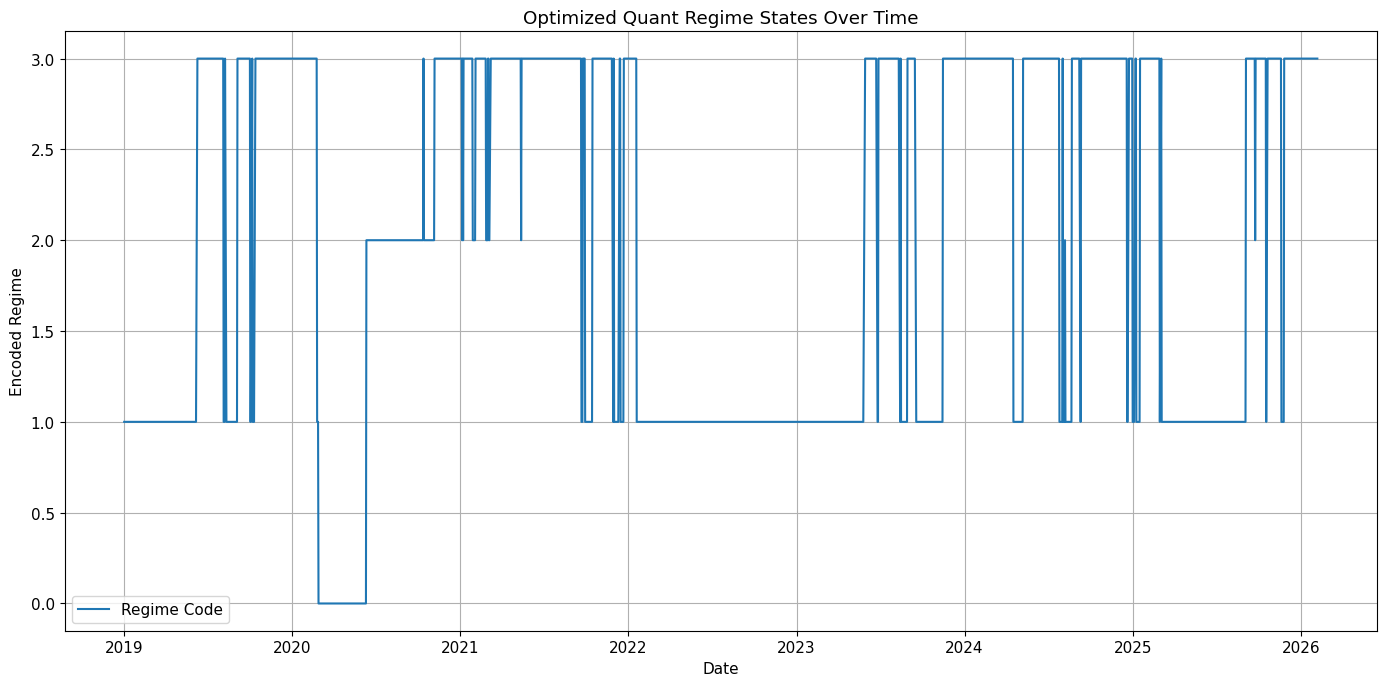

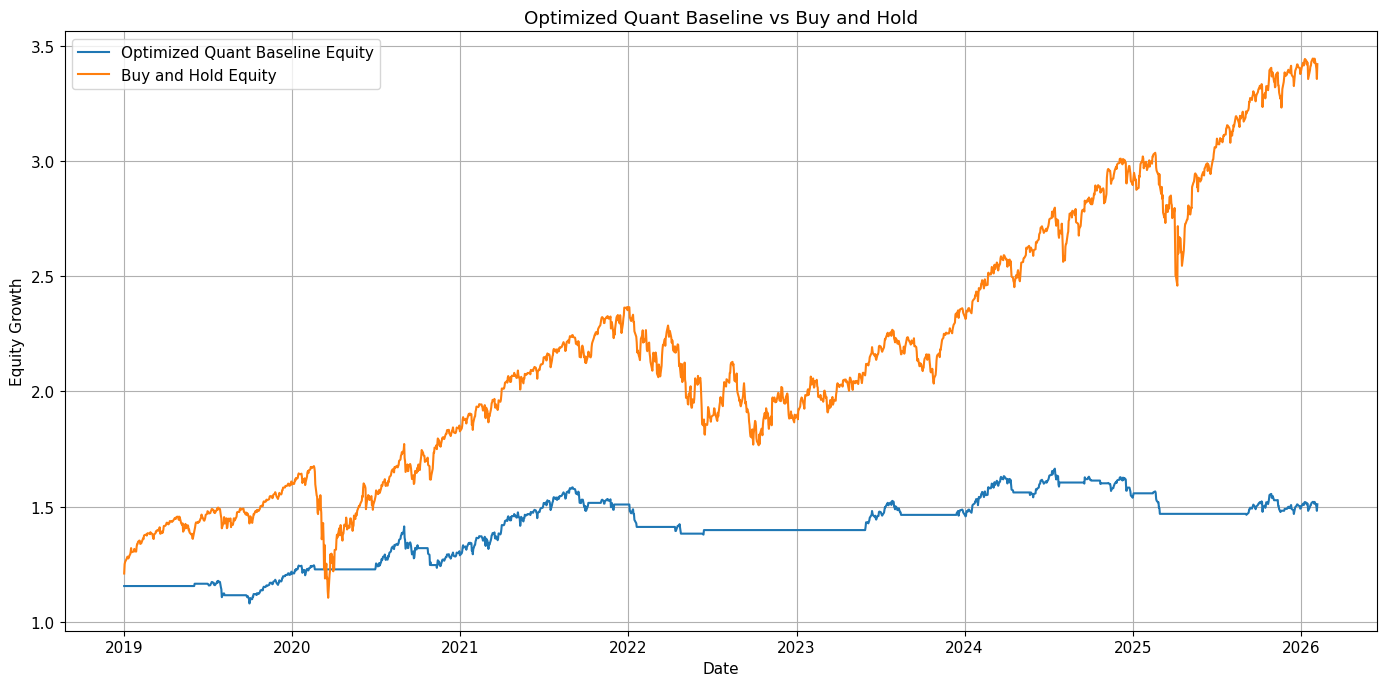

In [11]:
# ============================================
# Cell 10: Visualization of optimized regimes, signals, and quant baseline
# Purpose:
# - Visually inspect whether the optimized quant layer behaves sensibly over time
# - Compare optimized quant baseline to buy-and-hold
# - Save formal figures for later reporting
# ============================================

plot_data = quant_df.loc["2019-01-01":].copy()
plot_eval = quant_eval.loc["2019-01-01":].copy()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["spy_close"], label="SPY Close")
ax.scatter(
    plot_data.index[plot_data["quant_signal"] == 1],
    plot_data.loc[plot_data["quant_signal"] == 1, "spy_close"],
    label="Optimized Quant Buy Signal",
    marker="^",
)
ax.set_title("SPY Price with Optimized Quant Buy Signals")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_4_1_quant_buy_signals.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
regime_codes = plot_data["quant_regime_label"].astype("category").cat.codes
ax.plot(plot_data.index, regime_codes, label="Regime Code")
ax.set_title("Optimized Quant Regime States Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Encoded Regime")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_4_1_regime_states.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(plot_eval.index, plot_eval["quant_equity_curve"], label="Optimized Quant Baseline Equity")
ax.plot(plot_eval.index, plot_eval["buy_hold_equity_curve"], label="Buy and Hold Equity")
ax.set_title("Optimized Quant Baseline vs Buy and Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Equity Growth")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_4_1_quant_vs_buy_hold.png", dpi=150)
plt.show()

In [12]:
# ============================================
# Cell 11: Save Phase 4.1 outputs for Phase 5.1
# Purpose:
# - Persist the optimized quantitative layer outputs
# - Save the enriched dataset and metadata
# - Preserve a stable contract for the optimized ML phase
# ============================================

phase_4_1_csv_path = PROCESSED_DIR / "phase_4_1_quant_data.csv"
phase_4_1_parquet_path = PROCESSED_DIR / "phase_4_1_quant_data.parquet"
phase_4_1_regime_summary_csv_path = PROCESSED_DIR / "phase_4_1_regime_summary.csv"

quant_df.to_csv(phase_4_1_csv_path, index=True)
print(f"Saved CSV: {phase_4_1_csv_path}")

try:
    quant_df.to_parquet(phase_4_1_parquet_path, index=True)
    print(f"Saved Parquet: {phase_4_1_parquet_path}")
except Exception as e:
    print(f"Parquet save skipped: {e}")

regime_summary.to_csv(phase_4_1_regime_summary_csv_path, index=True)
print(f"Saved regime summary CSV: {phase_4_1_regime_summary_csv_path}")

phase_4_1_metadata = {
    "phase": "Phase 4.1 - Quantitative Model Layer (Optimized)",
    "source_notebook": "4.1 - Quantitative Model Layer (Optimized).ipynb",
    "row_count": int(len(quant_df)),
    "column_count": int(quant_df.shape[1]),
    "regime_value_counts": {
        str(k): int(v) for k, v in quant_df["quant_regime_label"].value_counts(dropna=False).to_dict().items()
    },
    "quant_signal_value_counts": {
        str(k): int(v) for k, v in quant_df["quant_signal"].value_counts(dropna=False).to_dict().items()
    },
    "start_date": str(quant_df.index.min().date()),
    "end_date": str(quant_df.index.max().date()),
}

phase_4_1_metadata_path = META_DIR / "phase_4_1_metadata.json"
with open(phase_4_1_metadata_path, "w", encoding="utf-8") as f:
    json.dump(phase_4_1_metadata, f, indent=4)

print(f"Saved metadata: {phase_4_1_metadata_path}")
print("Phase 4.1 output contract is ready for Phase 5.1.")

Saved CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_4_1_quant_data.csv
Saved Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_4_1_quant_data.parquet
Saved regime summary CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_4_1_regime_summary.csv
Saved metadata: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\reports\metadata\phase_4_1_metadata.json
Phase 4.1 output contract is ready for Phase 5.1.


In [13]:
# ============================================
# Cell 9: Regime-aware summary table
# Purpose:
# - Inspect whether the optimized quant logic behaves differently across regimes
# - Confirm that the regime-aware design is active and meaningful
# - Save an interpretable summary for downstream comparison
# ============================================

regime_summary = (
    quant_df.groupby("quant_regime_label")
    .agg(
        rows=("quant_signal", "size"),
        buy_signals=("quant_signal", "sum"),
        avg_quant_score=("quant_score", "mean"),
        avg_risk_score=("quant_risk_score", "mean"),
        avg_target_return_5d=("target_return_5d", "mean"),
    )
    .sort_values("rows", ascending=False)
)

print("Optimized regime summary:")
print(regime_summary)

Optimized regime summary:
                    rows  buy_signals  avg_quant_score  avg_risk_score  \
quant_regime_label                                                       
trending            1450         1085        -0.079510        0.321126   
mean_reverting      1128           29        -0.181778        0.673239   
transition           120           82        -0.027780        0.770726   
high_volatility       72            0        -0.439149        0.943986   

                    avg_target_return_5d  
quant_regime_label                        
trending                        0.001433  
mean_reverting                  0.003032  
transition                      0.009395  
high_volatility                 0.002766  
